# Step 13 — Structured + Text Model Comparison
### Credit Risk Prediction — Lending Club Dataset

**Question.** Does borrower text (`emp_title`, `title`, `desc`) add predictive value *beyond* the structured
credit-risk features?

**Cohort.** The authoritative Step 6 cohort — 41,988 loans (35,573 Good / 6,415 Bad). `credit_risk_step6_final.csv`
is the sole source of the cohort and the `target`; the target is never rebuilt from `loan_status`.
The raw file is used only to recover the three text fields, via Step 12's exact-match reconciliation (unchanged).

**Models compared — one shared stratified 80/20 split (`random_state=42`)**

| Model | Feature set | Pipeline | Role |
|---|---|---|---|
| **A — Structured only** | structured features | preprocessing → StandardScaler → PCA(0.95) → SMOTE → Logistic Regression (Step 9 best params, frozen) | Requested baseline (Steps 9–10) |
| **B — Structured + Text** | structured + TF-IDF | [preprocessing → StandardScaler] ‖ [TF-IDF] → horizontal stack → Logistic Regression (`class_weight='balanced'`) | Requested test model |
| **A-control — Structured only, matched classifier** | structured features | Same as B **minus the text block** | *Supplementary* — isolates the text effect |

**Why a supplementary control.** Model B cannot reuse Model A's recipe: PCA must not be applied to the sparse combined
matrix, and SMOTE is inappropriate for high-dimensional TF-IDF (Step 12 made the same call and used
`class_weight='balanced'`). So A → B changes *two* things at once — the classifier setup **and** the presence of text.
A-control keeps B's exact classifier setup and removes only the text block, so **A-control → B is the clean measure of
what text adds**. The requested A → B comparison is reported in full alongside it.

**This notebook does NOT:** use transformers / embeddings / RAG / GenAI, run SHAP, tune thresholds, add
XGBoost / Random Forest, run any hyperparameter search, apply PCA to the combined matrix, or use the Step 8
diagnostic SMOTE arrays. The test set is not transformed or scored until Section 7.

## 0. Setup

In [1]:
# imbalanced-learn is needed only for Model A (its SMOTE step); Colab does not ship it by default.
try:
    import imblearn
except ImportError:
    %pip install -q imbalanced-learn
    import imblearn

import os, warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

# --- Colab convenience (no-op elsewhere) ---
try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
except ImportError:
    pass

# --- Locate the two input files (project folder on Drive, working directory, or upload folder) ---
_SEARCH_DIRS = ['/content/drive/MyDrive/Credit_Risk_LendingClub', '.', '/content', '/mnt/user-data/uploads']
def find_file(name):
    for d in _SEARCH_DIRS:
        p = os.path.join(d, name)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"{name} not found in any of: {_SEARCH_DIRS}")

S6_PATH  = find_file('credit_risk_step6_final.csv')   # authoritative cohort + target
RAW_PATH = find_file('lending-club-loans.csv')        # raw source -- text columns only

RANDOM_STATE = 42
EXPECTED_COHORT_SIZE   = 41988
EXPECTED_TARGET_COUNTS = {0: 35573, 1: 6415}

print("imbalanced-learn:", imblearn.__version__)
print("Input files located: credit_risk_step6_final.csv, lending-club-loans.csv")

imbalanced-learn: 0.14.2
Input files located: credit_risk_step6_final.csv, lending-club-loans.csv


## 1. Load the authoritative Step 6 cohort

Dates are kept as the original strings for now: Step 12's reconciliation key is built from the string form of
`issue_d` / `earliest_cr_line`, and it is reproduced here unchanged. They are parsed after the text is recovered
(and, as in Step 7, are never model features).

In [2]:
s6 = pd.read_csv(S6_PATH, low_memory=False)
S6_COLUMNS = list(s6.columns)          # the original 37 Step 6 columns

assert len(s6) == EXPECTED_COHORT_SIZE, f"Expected {EXPECTED_COHORT_SIZE:,} rows, found {len(s6):,}."
assert s6['target'].value_counts().to_dict() == EXPECTED_TARGET_COUNTS, (
    f"Unexpected target distribution: {s6['target'].value_counts().to_dict()}")
assert s6.shape == (41988, 37), f"Unexpected shape: {s6.shape}"

print(f"Step 6 cohort: {s6.shape[0]:,} rows x {s6.shape[1]} columns")
print(f"Good (0) = {(s6['target'] == 0).sum():,}   Bad (1) = {(s6['target'] == 1).sum():,}   "
      f"-> verified against the authoritative counts. Target is used exactly as stored.")

Step 6 cohort: 41,988 rows x 37 columns
Good (0) = 35,573   Bad (1) = 6,415   -> verified against the authoritative counts. Target is used exactly as stored.


## 2. Recover borrower text — Step 12 reconciliation (unchanged logic)

`emp_title`, `title` and `desc` are not in the Step 6 file. They are recovered from the raw file with the same
13-field exact-match composite key and `emp_length_years` tie-break used in Steps 11–12 — never fuzzy or positional
matching. `loan_status` is used **only** to decide which raw rows are eligible match candidates; it never touches
`target`. The matching loop below is a faster but logically identical implementation of Step 12's, and its result is
asserted against Step 12's reported counts (41,984 matched / 4 unmatched / 0 ambiguous).

In [3]:
raw = pd.read_csv(RAW_PATH, low_memory=False, encoding='ISO-8859-1')
print(f"Raw file: {raw.shape[0]:,} rows x {raw.shape[1]} columns")

# Step 2's resolved-loan definition -- used ONLY to filter eligible raw candidates for matching.
BAD_STATUSES  = ['Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off']
GOOD_STATUSES = ['Fully Paid', 'Does not meet the credit policy. Status:Fully Paid']

raw_resolved = raw[raw['loan_status'].isin(BAD_STATUSES + GOOD_STATUSES)].copy()
valid_date_or_na = (raw_resolved['earliest_cr_line'].isna() |
                    raw_resolved['earliest_cr_line'].astype(str).str.match(r'^\s*[A-Za-z]{3}-\d{2}\s*$'))
n_corrupted = int((~valid_date_or_na).sum())
raw_resolved = raw_resolved[valid_date_or_na].copy()
print(f"Dropped for corrupted earliest_cr_line: {n_corrupted}   |   raw candidate pool: {len(raw_resolved):,}")

def parse_mon_yy_fix_century(s, pivot_year=2020):
    '''Parse Mon-YY dates, fixing pandas' %y century pivot for dates before 1969 (Sep-62 -> 1962, not 2062).'''
    dt = pd.to_datetime(s, format='%b-%y', errors='coerce')
    return dt.mask(dt.dt.year > pivot_year, dt - pd.DateOffset(years=100))

EMP_LEN_MAP = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4, '5 years': 5,
               '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10}

raw_resolved['term_n']             = raw_resolved['term'].str.extract(r'(\d+)').astype(float)
raw_resolved['int_rate_n']         = raw_resolved['int_rate'].str.rstrip('%').astype(float)
raw_resolved['dti_n']              = pd.to_numeric(raw_resolved['dti'], errors='coerce')
raw_resolved['open_acc_n']         = pd.to_numeric(raw_resolved['open_acc'], errors='coerce')
raw_resolved['inq_last_6mths_n']   = pd.to_numeric(raw_resolved['inq_last_6mths'], errors='coerce')
raw_resolved['issue_d_n']          = parse_mon_yy_fix_century(raw_resolved['issue_d']).dt.strftime('%Y-%m-01')
raw_resolved['earliest_cr_line_n'] = parse_mon_yy_fix_century(
    raw_resolved['earliest_cr_line'].astype(str).str.strip()).dt.strftime('%Y-%m-01')
raw_resolved['emp_length_years_n'] = raw_resolved['emp_length'].map(EMP_LEN_MAP)

KEY_COLS_S6  = ['loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc', 'dti', 'issue_d',
                'earliest_cr_line', 'open_acc', 'revol_bal', 'total_acc', 'delinq_amnt', 'inq_last_6mths']
KEY_COLS_RAW = ['loan_amnt', 'term_n', 'int_rate_n', 'installment', 'annual_inc', 'dti_n', 'issue_d_n',
                'earliest_cr_line_n', 'open_acc_n', 'revol_bal', 'total_acc', 'delinq_amnt', 'inq_last_6mths_n']
IS_NUMERIC   = [True, True, True, True, True, True, False, False, True, True, True, True, True]

def make_key(frame, cols, numeric_flags):
    parts = []
    for c, is_num in zip(cols, numeric_flags):
        v = frame[c]
        if is_num:
            v = pd.to_numeric(v, errors='coerce').astype(float).round(4)
        s = v.astype(str)
        parts.append(s.where(~v.isna(), 'NA'))
    key = parts[0]
    for p in parts[1:]:
        key = key.str.cat(p, sep='|')
    return key

s6['_key']         = make_key(s6, KEY_COLS_S6, IS_NUMERIC)
raw_resolved['_key'] = make_key(raw_resolved, KEY_COLS_RAW, IS_NUMERIC)
print("Composite match key built on both files.")

Raw file: 42,538 rows x 117 columns
Dropped for corrupted earliest_cr_line: 1   |   raw candidate pool: 41,988


Composite match key built on both files.


In [4]:
# --- Exact-match reconciliation (matched / tie-break / unmatched / ambiguous) ---
raw_groups = raw_resolved.groupby('_key').indices          # key -> positions in raw_resolved
raw_emp_len = raw_resolved['emp_length_years_n'].to_numpy()

status, positions = [], []
for key, emp_len in zip(s6['_key'].to_numpy(), s6['emp_length_years'].to_numpy()):
    cand = raw_groups.get(key)
    if cand is None:
        status.append('unmatched');  positions.append(-1)
    elif len(cand) == 1:
        status.append('matched');    positions.append(cand[0])
    else:
        tie = [p for p in cand if raw_emp_len[p] == emp_len]
        if len(tie) == 1:
            status.append('matched_tiebreak_emp_length'); positions.append(tie[0])
        else:
            status.append('ambiguous');                    positions.append(-1)

positions = np.asarray(positions)
TEXT_COLS = ['emp_title', 'title', 'desc']
for c in TEXT_COLS:
    src = raw_resolved[c].to_numpy(dtype=object)
    s6[c] = np.where(positions >= 0, src[np.clip(positions, 0, None)], np.nan)

status = pd.Series(status)
n_matched   = int(status.isin(['matched', 'matched_tiebreak_emp_length']).sum())
n_unmatched = int((status == 'unmatched').sum())
n_ambiguous = int((status == 'ambiguous').sum())
print(f"Matched (text recovered): {n_matched:,} ({n_matched / len(s6) * 100:.2f}%)   "
      f"Unmatched: {n_unmatched}   Ambiguous: {n_ambiguous}")

# Must reproduce Step 12 exactly, and must not have altered the cohort/target.
assert (n_matched, n_unmatched, n_ambiguous) == (41984, 4, 0), "Reconciliation does not match Step 12."
assert len(s6) == EXPECTED_COHORT_SIZE and s6['target'].value_counts().to_dict() == EXPECTED_TARGET_COUNTS
print("Reconciliation matches Step 12; cohort and target unchanged.")

del raw, raw_resolved, raw_groups      # free memory -- no longer needed

Matched (text recovered): 41,984 (99.99%)   Unmatched: 4   Ambiguous: 0
Reconciliation matches Step 12; cohort and target unchanged.


## 3. Combine text fields into one representation

`emp_title`, `title` and `desc` are concatenated into one `combined_text` field. Missing text becomes an empty
string (rows are never dropped). Dates are then parsed, and the modeling frame is assembled from the original 37
Step 6 columns plus `combined_text`.

In [5]:
for c in TEXT_COLS:
    s6[c] = s6[c].fillna('')
s6['combined_text'] = (s6['emp_title'] + ' ' + s6['title'] + ' ' + s6['desc']).str.strip()

coverage = pd.DataFrame({
    'non-empty rows': [(s6[c].str.strip() != '').sum() for c in TEXT_COLS] + [(s6['combined_text'] != '').sum()],
}, index=TEXT_COLS + ['combined_text'])
coverage['% of cohort'] = (coverage['non-empty rows'] / len(s6) * 100).round(2)
display(coverage)
print(f"Rows with completely empty combined text: {(s6['combined_text'] == '').sum()}")

# Modeling frame: original 37 Step 6 columns + combined_text (helper/key columns dropped)
df = s6[S6_COLUMNS + ['combined_text']].copy()
df['issue_d'] = pd.to_datetime(df['issue_d'])                    # reference only, not a feature (Step 7)
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])  # reference only, not a feature (Step 7)
print(f"\nModeling frame: {df.shape[0]:,} rows x {df.shape[1]} columns")

,non-empty rows,% of cohort
emp_title,39402,93.84
title,41971,99.96
desc,28666,68.27
combined_text,41983,99.99


Rows with completely empty combined text: 5

Modeling frame: 41,988 rows x 38 columns


## 4. One stratified 80/20 split shared by every model

A single `train_test_split(..., stratify=target, random_state=42)` is applied to the full frame, so the structured
features, the text, and the target are split **together** and every model sees the same rows. Only the training
portion is unpacked here; the test rows stay inside `test_df` and are not transformed or scored until Section 7.

In [6]:
NON_FEATURE_COLS = ['target', 'issue_d', 'earliest_cr_line', 'combined_text']

train_df, test_df = train_test_split(
    df, test_size=0.20, stratify=df['target'], random_state=RANDOM_STATE
)

# Cross-check: the split is identical to the ones used in Steps 7-10 (structured) and Step 12 (text, split on the text
# Series alone). Identical n + identical stratify labels + identical seed => identical row assignment.
_s12_tr, _s12_te, _, _ = train_test_split(df['combined_text'], df['target'], test_size=0.20,
                                          stratify=df['target'], random_state=42)
assert train_df.index.equals(_s12_tr.index) and test_df.index.equals(_s12_te.index), "Split differs from Step 12."

assert train_df.shape[0] == 33590 and test_df.shape[0] == 8398
assert train_df['target'].value_counts().to_dict() == {0: 28458, 1: 5132}
assert test_df['target'].value_counts().to_dict()  == {0: 7115,  1: 1283}

print(f"Train: {len(train_df):,} rows   Test: {len(test_df):,} rows  (test held aside, untouched until Section 7)")
print(f"Train target: {train_df['target'].value_counts().to_dict()}")
print(f"Test  target: {test_df['target'].value_counts().to_dict()}   (label counts shown only to confirm stratification)")
print("Split matches Steps 7-10 and Step 12.")

# Training objects only
X_train      = train_df.drop(columns=NON_FEATURE_COLS)
y_train      = train_df['target'].copy()
text_train   = train_df['combined_text']

Train: 33,590 rows   Test: 8,398 rows  (test held aside, untouched until Section 7)
Train target: {0: 28458, 1: 5132}
Test  target: {0: 7115, 1: 1283}   (label counts shown only to confirm stratification)
Split matches Steps 7-10 and Step 12.


## 5. Structured preprocessing — the finalized Step 7 definition, unchanged

Same numerical / categorical feature groups and the same `ColumnTransformer` as Steps 7–10: median imputation for
numerics; most-frequent imputation + `OneHotEncoder(handle_unknown='ignore')` for categoricals. Every clone of it
below is fitted on the training rows only.

In [7]:
numerical_features = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'annual_inc', 'dti',
    'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
    'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'delinq_amnt',
    'pub_rec_bankruptcies', 'credit_history_months', 'loan_to_income',
    'installment_to_income', 'revol_bal_to_income', 'open_acc_ratio',
    'fico_avg', 'grade_ordinal', 'emp_length_years',
    'has_public_record', 'has_delinquency', 'pub_rec_bankruptcies_missing',
    'revol_util_missing', 'emp_length_missing', 'is_income_verified'
]
categorical_features = ['verification_status', 'addr_state', 'dti_bin',
                        'home_ownership_grouped', 'purpose_grouped']
STRUCTURED_FEATURES = numerical_features + categorical_features

assert set(STRUCTURED_FEATURES) == set(X_train.columns) and len(STRUCTURED_FEATURES) == X_train.shape[1] == 34

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), numerical_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
     categorical_features),
])
print(f"Raw structured features: {len(STRUCTURED_FEATURES)} "
      f"({len(numerical_features)} numerical + {len(categorical_features)} categorical)")

Raw structured features: 34 (29 numerical + 5 categorical)


## 6. Fit on the training data only

### 6a. Model A — Structured only (Step 9 / Step 10 model)

The Step 9 `GridSearchCV` selected Logistic Regression with `C=10`, `penalty='l2'`, `solver='liblinear'`
(best CV PR-AUC 0.2931, ahead of the Decision Tree at 0.2463 and Random Forest at 0.2923). Those parameters are
**frozen** here and the pipeline is fit once on `X_train` — no search is rerun. (`penalty='l2'` is scikit-learn's
default, so it is left implicit.) Section 10 checks that this reproduces the Step 10 test numbers.

In [8]:
STEP9_BEST_LR = dict(C=10, solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)

model_A = ImbPipeline(steps=[
    ('preprocessing', clone(preprocessor)),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(**STEP9_BEST_LR)),
])
model_A.fit(X_train, y_train)          # SMOTE is applied at fit time only, inside the pipeline

print("Model A fitted on X_train only.")
print(f"PCA components retained (95% variance): {model_A.named_steps['pca'].n_components_}")

Model A fitted on X_train only.
PCA components retained (95% variance): 79


### 6b. Feature representations for Model B (and the A-control)

- **Structured block** — the Step 7 preprocessor followed by `StandardScaler`, both fit on the training rows. Step 7
  deliberately deferred scaling to the model stage (“if a scaled linear model is chosen later, scaling will be added as
  its own explicit step”), and Step 9's Logistic Regression used `StandardScaler` for exactly this reason. Without it,
  columns such as `annual_inc` (tens of thousands) would swamp TF-IDF values (0–1) under L2 regularization. No PCA.
- **Text block** — `TfidfVectorizer` with the Step 12 settings, **fit on the training text only**.
- **Combination** — horizontal sparse stack `[structured | TF-IDF]`.

In [9]:
TFIDF_CONFIG = dict(lowercase=True, stop_words='english', ngram_range=(1, 2), min_df=5, max_df=0.95)  # Step 12

# Structured block (fit on train only)
struct_prep   = clone(preprocessor)
struct_scaler = StandardScaler()
S_train = struct_scaler.fit_transform(struct_prep.fit_transform(X_train))

# Text block (fit on train only)
vectorizer = TfidfVectorizer(**TFIDF_CONFIG)
T_train = vectorizer.fit_transform(text_train)

# Horizontal combination (training representation)
B_train = sp.hstack([sp.csr_matrix(S_train), T_train], format='csr')

# --- Feature counts ---
ohe_names = struct_prep.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
n_struct  = S_train.shape[1]
n_tfidf   = T_train.shape[1]
n_total   = B_train.shape[1]
assert n_struct == len(numerical_features) + len(ohe_names) and n_total == n_struct + n_tfidf

print("FEATURE COUNTS")
print("=" * 52)
print(f"Structured features after preprocessing : {n_struct:>7,}   ({len(numerical_features)} numeric + {len(ohe_names)} one-hot)")
print(f"TF-IDF features                         : {n_tfidf:>7,}")
print(f"Total combined features (Model B)       : {n_total:>7,}")
print(f"\nTrain matrices: structured {S_train.shape}, TF-IDF {T_train.shape}, combined {B_train.shape}")
print(f"Combined matrix density: {B_train.nnz / (B_train.shape[0] * B_train.shape[1]):.4%}  (sparse; no PCA applied)")

FEATURE COUNTS
Structured features after preprocessing :     101   (29 numeric + 72 one-hot)
TF-IDF features                         :  29,988
Total combined features (Model B)       :  30,089

Train matrices: structured (33590, 101), TF-IDF (33590, 29988), combined (33590, 30089)
Combined matrix density: 0.4683%  (sparse; no PCA applied)


### 6c. Fit Model B and the A-control

Both use the Step 12 classifier configuration — `class_weight='balanced'`, `solver='liblinear'`, `max_iter=1000`,
`random_state=42`, default `C=1` — so the *only* difference between them is the text block. No tuning.

In [10]:
LOGREG_CONFIG = dict(class_weight='balanced', solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)

model_A_ctrl = LogisticRegression(**LOGREG_CONFIG).fit(S_train, y_train)   # structured only
model_B      = LogisticRegression(**LOGREG_CONFIG).fit(B_train, y_train)   # structured + text

print("A-control (structured only) and Model B (structured + text) fitted on training data only.")
print("Shared classifier config:", LOGREG_CONFIG)

A-control (structured only) and Model B (structured + text) fitted on training data only.
Shared classifier config: {'class_weight': 'balanced', 'solver': 'liblinear', 'max_iter': 1000, 'random_state': 42}


## 7. Score the untouched test set — first and only use

The test rows are unpacked and transformed **now**, using the objects fitted in Section 6 (`.transform` only — no
refitting of the preprocessor, scaler or vectorizer on test data).

In [11]:
X_test    = test_df.drop(columns=NON_FEATURE_COLS)
y_test    = test_df['target'].copy()
text_test = test_df['combined_text']

S_test = struct_scaler.transform(struct_prep.transform(X_test))     # transform only
T_test = vectorizer.transform(text_test)                            # transform only (train vocabulary / IDF)
B_test = sp.hstack([sp.csr_matrix(S_test), T_test], format='csr')

assert S_test.shape[1] == n_struct and T_test.shape[1] == n_tfidf and B_test.shape[1] == n_total
print(f"Test matrices: structured {S_test.shape}, TF-IDF {T_test.shape}, combined {B_test.shape}")

preds = {
    'A':      {'pred': model_A.predict(X_test),        'proba': model_A.predict_proba(X_test)[:, 1]},
    'A_ctrl': {'pred': model_A_ctrl.predict(S_test),   'proba': model_A_ctrl.predict_proba(S_test)[:, 1]},
    'B':      {'pred': model_B.predict(B_test),        'proba': model_B.predict_proba(B_test)[:, 1]},
}
y_test_arr = y_test.to_numpy()
print("Predictions generated for all models on the same 8,398 test rows.")

Test matrices: structured (8398, 101), TF-IDF (8398, 29988), combined (8398, 30089)
Predictions generated for all models on the same 8,398 test rows.


## 8. Test-set metrics

Bad (`target == 1`) is the positive class. Precision, recall and F1 use the models' default 0.5 decision rule —
no threshold tuning, per scope. ROC-AUC and PR-AUC are threshold-free.

In [12]:
METRICS = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

def compute_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
        'ROC-AUC':   roc_auc_score(y_true, y_proba),
        'PR-AUC':    average_precision_score(y_true, y_proba),
    }

LABELS = {
    'A':      'A - Structured Only (Step 9/10)',
    'B':      'B - Structured + Text',
    'A_ctrl': 'A-control - Structured Only, matched LR',
}
results = {k: compute_metrics(y_test_arr, v['pred'], v['proba']) for k, v in preds.items()}

def metrics_table(keys):
    t = pd.DataFrame([{'Model': LABELS[k], **results[k]} for k in keys])[['Model'] + METRICS]
    return t.round(4).set_index('Model')

print("TABLE 1 - Requested comparison (Structured Only -> Structured + Text)")
display(metrics_table(['A', 'B']))

print("TABLE 2 - Supplementary control: same classifier setup, text block is the only difference")
display(metrics_table(['A_ctrl', 'B']))

print(f"Reference points on this test set: ROC-AUC no-skill = 0.5000 | "
      f"PR-AUC no-skill = Bad base rate = {y_test_arr.mean():.4f}")

TABLE 1 - Requested comparison (Structured Only -> Structured + Text)


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
A - Structured Only (Step 9/10),0.6550,0.2488,0.6228,0.3555,0.7082,0.3036
B - Structured + Text,0.7106,0.2707,0.5277,0.3578,0.7132,0.3047


TABLE 2 - Supplementary control: same classifier setup, text block is the only difference


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
"A-control - Structured Only, matched LR",0.6633,0.2590,0.6469,0.3699,0.7184,0.3132
B - Structured + Text,0.7106,0.2707,0.5277,0.3578,0.7132,0.3047


Reference points on this test set: ROC-AUC no-skill = 0.5000 | PR-AUC no-skill = Bad base rate = 0.1528


A - Structured Only (Step 9/10)


,Pred: Good (0),Pred: Bad (1)
Actual: Good (0),4702,2413
Actual: Bad (1),484,799


   TN=4,702  FP=2,413  FN=484  TP=799

B - Structured + Text


,Pred: Good (0),Pred: Bad (1)
Actual: Good (0),5291,1824
Actual: Bad (1),606,677


   TN=5,291  FP=1,824  FN=606  TP=677

A-control - Structured Only, matched LR


,Pred: Good (0),Pred: Bad (1)
Actual: Good (0),4740,2375
Actual: Bad (1),453,830


   TN=4,740  FP=2,375  FN=453  TP=830



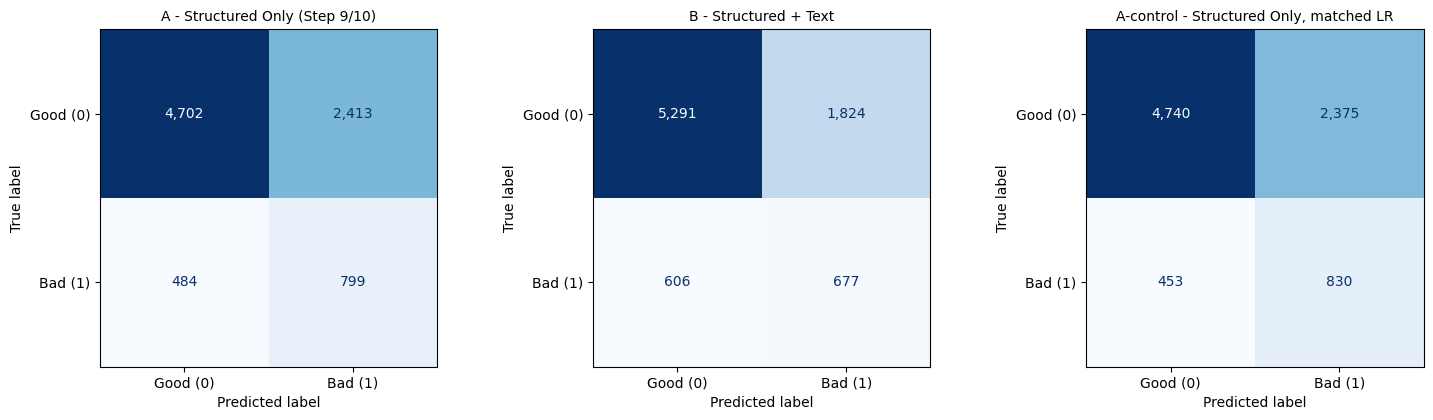

In [13]:
cms = {k: confusion_matrix(y_test_arr, v['pred']) for k, v in preds.items()}

for k in ['A', 'B', 'A_ctrl']:
    tn, fp, fn, tp = cms[k].ravel()
    print(f"{LABELS[k]}")
    display(pd.DataFrame(cms[k], index=['Actual: Good (0)', 'Actual: Bad (1)'],
                         columns=['Pred: Good (0)', 'Pred: Bad (1)']))
    print(f"   TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, k in zip(axes, ['A', 'B', 'A_ctrl']):
    ConfusionMatrixDisplay(cms[k], display_labels=['Good (0)', 'Bad (1)']).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format=',d')
    ax.set_title(LABELS[k], fontsize=10)
plt.tight_layout()
plt.show()

## 9. Change from Structured Only → Structured + Text

Two comparisons are reported:

- **A → B** — the requested comparison (Step 9/10 model vs. the combined model). Because the classifier setup also
  changes, this alone cannot attribute a difference to text.
- **A-control → B** — identical classifier setup; text is the only difference, so this isolates the text effect.

**Noise check.** A point difference on ~8.4k test rows can be noise, so each delta gets a 95% *paired* bootstrap
interval: the same resampled test rows are scored by both models (1,000 resamples, seed 42). This uses the fixed test
predictions only — nothing is refit and nothing is tuned. It captures test-sample variability, not training-run
variability. **Decision rule (fixed before looking at results):** text is credited with incremental signal only if
ROC-AUC **and** PR-AUC both improve *and* their 95% intervals exclude zero. F1 is reported but is not the deciding
metric, because it depends on the default 0.5 cut-off and no threshold tuning is permitted.

In [14]:
N_BOOT = 1000
rng = np.random.default_rng(RANDOM_STATE)
n_test = len(y_test_arr)

boot = {k: {m: np.empty(N_BOOT) for m in ['F1', 'ROC-AUC', 'PR-AUC']} for k in preds}
for b in range(N_BOOT):
    idx = rng.integers(0, n_test, n_test)        # same resampled rows for every model (paired)
    yb = y_test_arr[idx]
    for k, v in preds.items():
        boot[k]['F1'][b]      = f1_score(yb, v['pred'][idx])
        boot[k]['ROC-AUC'][b] = roc_auc_score(yb, v['proba'][idx])
        boot[k]['PR-AUC'][b]  = average_precision_score(yb, v['proba'][idx])

def delta_table(old, new, name):
    rows = []
    for m in ['F1', 'ROC-AUC', 'PR-AUC']:
        d_point = results[new][m] - results[old][m]
        d_boot = boot[new][m] - boot[old][m]
        lo, hi = np.percentile(d_boot, [2.5, 97.5])
        rows.append({'Comparison': name, 'Metric': m,
                     'Before': results[old][m], 'After': results[new][m],
                     'Change': d_point, 'CI low': lo, 'CI high': hi,
                     'CI excludes 0': bool(lo > 0 or hi < 0)})
    return pd.DataFrame(rows)

deltas = pd.concat([
    delta_table('A', 'B', 'A -> B (requested)'),
    delta_table('A_ctrl', 'B', 'A-control -> B (text isolated)'),
], ignore_index=True)

display(deltas.round(4).set_index(['Comparison', 'Metric']).style.format(
    {'Before': '{:.4f}', 'After': '{:.4f}', 'Change': '{:+.4f}', 'CI low': '{:+.4f}', 'CI high': '{:+.4f}'}))

In [15]:
def get(comp_prefix, metric):
    return deltas[(deltas['Comparison'].str.startswith(comp_prefix)) & (deltas['Metric'] == metric)].iloc[0]

def improves_significantly(comp_prefix):
    return all((get(comp_prefix, m)['Change'] > 0) and (get(comp_prefix, m)['CI low'] > 0)
               for m in ['ROC-AUC', 'PR-AUC'])

def direction(comp_prefix):
    ch = [get(comp_prefix, m)['Change'] for m in ['F1', 'ROC-AUC', 'PR-AUC']]
    return 'all three positive' if all(c > 0 for c in ch) else ('all three negative' if all(c < 0 for c in ch) else 'mixed')

req_sig, iso_sig = improves_significantly('A ->'), improves_significantly('A-control')
TEXT_HELPS = iso_sig     # the isolation comparison is the one that can attribute a change to text

print("VERDICT (rule fixed in Section 9)")
print("=" * 78)
print(f"A -> B (requested):            point changes {direction('A ->')}; "
      f"ROC-AUC and PR-AUC both improve with CI excluding 0? {req_sig}")
print(f"A-control -> B (text isolated): point changes {direction('A-control')}; "
      f"ROC-AUC and PR-AUC both improve with CI excluding 0? {iso_sig}")
print()
if TEXT_HELPS:
    print("=> Text improves ROC-AUC and PR-AUC beyond the like-for-like structured model, with intervals "
          "excluding zero: the results suggest borrower text carries incremental predictive signal beyond "
          "the structured credit features.")
else:
    print("=> This experiment did NOT demonstrate useful incremental predictive value from borrower text. "
          "Against the like-for-like structured model, text does not improve ROC-AUC and PR-AUC with intervals "
          "excluding zero. Any small gain in the requested A -> B comparison is not attributable to text and "
          "is not distinguishable from noise; the NLP component is not pursued further.")

VERDICT (rule fixed in Section 9)
A -> B (requested):            point changes all three positive; ROC-AUC and PR-AUC both improve with CI excluding 0? False
A-control -> B (text isolated): point changes all three negative; ROC-AUC and PR-AUC both improve with CI excluding 0? False

=> This experiment did NOT demonstrate useful incremental predictive value from borrower text. Against the like-for-like structured model, text does not improve ROC-AUC and PR-AUC with intervals excluding zero. Any small gain in the requested A -> B comparison is not attributable to text and is not distinguishable from noise; the NLP component is not pursued further.


## 10. Reproducibility and leakage checks

In [16]:
checks = []
def check(name, cond): checks.append((name, bool(cond))); print(f"[{'PASS' if cond else 'FAIL'}] {name}")

check("Cohort = 41,988 rows; Good = 35,573, Bad = 6,415 (Step 6 target used as stored)",
      len(df) == 41988 and df['target'].value_counts().to_dict() == {0: 35573, 1: 6415})
check("Split: stratified 80/20, random_state=42 -> 33,590 train / 8,398 test, class counts as in Step 7",
      len(train_df) == 33590 and len(test_df) == 8398 and
      train_df['target'].value_counts().to_dict() == {0: 28458, 1: 5132} and
      test_df['target'].value_counts().to_dict() == {0: 7115, 1: 1283})
check("All three models were scored on the identical test rows",
      all(len(v['pred']) == len(test_df) for v in preds.values()))
check("Text reconciliation identical to Step 12 (41,984 matched / 4 unmatched / 0 ambiguous)",
      (n_matched, n_unmatched, n_ambiguous) == (41984, 4, 0))
check("TF-IDF fitted on train text only; vocabulary size matches Step 12 (29,988)",
      n_tfidf == 29988 and vectorizer.transform(text_train[:5]).shape[1] == n_tfidf)
check("TF-IDF settings = Step 12 (lowercase, english stop words, (1,2)-grams, min_df=5, max_df=0.95)",
      vectorizer.get_params()['ngram_range'] == (1, 2) and vectorizer.get_params()['min_df'] == 5 and
      vectorizer.get_params()['max_df'] == 0.95 and vectorizer.get_params()['stop_words'] == 'english' and
      vectorizer.get_params()['lowercase'] is True)
check("Combined feature count = structured + TF-IDF, identical in train and test",
      n_total == n_struct + n_tfidf and B_train.shape[1] == B_test.shape[1])
check("No NaNs in the structured block (train or test)",
      not np.isnan(S_train).any() and not np.isnan(S_test).any())
check("No PCA / SMOTE in Model B's path (plain sparse stack -> LogisticRegression)",
      isinstance(model_B, LogisticRegression) and model_B.class_weight == 'balanced')
check("Model A pipeline = preprocessing -> scaler -> PCA -> SMOTE -> LR with frozen Step 9 params",
      [n for n, _ in model_A.steps] == ['preprocessing', 'scaler', 'pca', 'smote', 'classifier'] and
      model_A.named_steps['classifier'].C == 10 and model_A.named_steps['classifier'].solver == 'liblinear')

# Model A must reproduce the Step 10 saved test-set results (Logistic Regression row + confusion matrix).
STEP10_LR = {'Accuracy': 0.6550, 'Precision': 0.2488, 'Recall': 0.6228, 'F1': 0.3555, 'ROC-AUC': 0.7082, 'PR-AUC': 0.3036}
check("Model A reproduces Step 10's Logistic Regression test metrics (all six within 0.002)",
      all(abs(results['A'][m] - STEP10_LR[m]) < 0.002 for m in METRICS))
check("Model A confusion matrix reproduces Step 10 (TN=4702, FP=2413, FN=484, TP=799)",
      tuple(cms['A'].ravel()) == (4702, 2413, 484, 799))

print()
assert all(ok for _, ok in checks), "One or more checks failed -- see above."
print(f"ALL {len(checks)} CHECKS PASSED")
print("Not used anywhere in this notebook: transformers, embeddings, RAG, GenAI, SHAP, threshold tuning, "
      "XGBoost/Random Forest, hyperparameter search, Step 8 SMOTE arrays, loan_status-derived targets.")

[PASS] Cohort = 41,988 rows; Good = 35,573, Bad = 6,415 (Step 6 target used as stored)
[PASS] Split: stratified 80/20, random_state=42 -> 33,590 train / 8,398 test, class counts as in Step 7
[PASS] All three models were scored on the identical test rows
[PASS] Text reconciliation identical to Step 12 (41,984 matched / 4 unmatched / 0 ambiguous)
[PASS] TF-IDF fitted on train text only; vocabulary size matches Step 12 (29,988)
[PASS] TF-IDF settings = Step 12 (lowercase, english stop words, (1,2)-grams, min_df=5, max_df=0.95)
[PASS] Combined feature count = structured + TF-IDF, identical in train and test
[PASS] No NaNs in the structured block (train or test)
[PASS] No PCA / SMOTE in Model B's path (plain sparse stack -> LogisticRegression)
[PASS] Model A pipeline = preprocessing -> scaler -> PCA -> SMOTE -> LR with frozen Step 9 params
[PASS] Model A reproduces Step 10's Logistic Regression test metrics (all six within 0.002)
[PASS] Model A confusion matrix reproduces Step 10 (TN=4702, 

## Business Interpretation

**What was tested.** Whether the free text a borrower supplies — employer title, loan title, loan description — helps
rank applicants by default risk *after* the structured credit features (loan terms, bureau attributes, grade, income
ratios) are already in the model.

**What the comparison shows.** Adding roughly 30,000 TF-IDF text features to the 101 structured features did not
produce a measurable gain in separating Bad from Good loans. In the requested A → B comparison, F1, ROC-AUC and
PR-AUC all edge up slightly, but every 95% interval includes zero. The like-for-like control shows why that small
uptick should not be credited to text: with the classifier setup held fixed, adding the text block moved all three
metrics slightly *down* — again within noise (Section 9). So there is no evidence here that text helps, and no firm
evidence that it hurts either. The experiment **did not demonstrate useful incremental predictive value from
borrower text**, and the NLP component is not pursued further.

**What this means for a credit-risk use case.**
- On this evidence, there is no performance case for adding a free-text pipeline to the scoring model. The structured
  credit features remain the primary and sufficient signal here; text would add feature volume, maintenance and
  monitoring burden without measurable lift.
- Free-text inputs carry extra governance cost regardless of lift: they are self-reported and easy to game or
  template, they can act as proxies for characteristics a lender may not use, and word-level model behavior is harder
  to justify in an adverse-action or model-risk review than a ratio or a bureau attribute.
- Text alone is not noise — Step 12 found it modestly better than chance (ROC-AUC ≈ 0.61 on its own). That it adds
  nothing on top of structured features is *consistent with* the text signal largely overlapping information
  already captured by structured fields (for example loan purpose and amount), but that overlap is a hypothesis this
  experiment did not test.

**Cautions on reading this result.**
- These are predictive associations on a historical, already-resolved LendingClub cohort — not causal claims. Nothing
  here says that any wording *causes* repayment or default.
- The conclusion is specific to one text representation (TF-IDF, Step 12 settings), one linear classifier at its default
  regularization, and untuned weighting between the structured and text blocks. It shows that *this* configuration
  gave no demonstrated lift; it does not prove that no text-based approach ever could.
- Model B shows higher accuracy and precision but lower recall than Model A (Table 1). With ROC-AUC and PR-AUC essentially unchanged, that is consistent with a shift in operating point at the default 0.5 cut-off rather than better risk ranking — which is why the threshold-free metrics carry the verdict.
- Precision, recall and F1 use the default 0.5 cut-off. A production decision would set a cut-off from the relative
  cost of missed defaults versus declined good borrowers, which is deliberately outside this step.
- Intervals reflect test-sample variability for fixed fitted models, not variability across retraining.